In [62]:

import numpy as np
from tqdm import trange
from pathlib import Path
import matplotlib.pyplot as plt
import time
import sys
import pandas as pd
import scipy
import sympy as sp
from scipy.interpolate import interp1d


import sklearn.gaussian_process as gp
from scipy import stats


sys.path.append('../..')
sys.path.append('..')
import plot_settings
import importlib
#import multi_exp_log
#import Param_symbol

import GP



from IPython.display import display, Math

colors = plot_settings.colors()

def import_reload():
    plot_settings.apply()
    importlib.reload(GP)

import_reload()
GP_FIT = GP.GP_process()

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/5_Multi/sr/../GP.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


# Importing data

In [38]:
RUN_ID = 'all1'
DT = 1
Q0 = 17921.57581 

## ECM solver module

In [182]:
# Extract expressions from symbolic regression results
def extract_expressions(run_id):
    # Load the symbolic regression results
    elements = ['k', 'R1', 'C1']
    
    expressions = {}

    for elem in elements:
    
        results_path = Path(f'sr_models/model_{elem}_{run_id}.csv')
        if not results_path.exists():
            raise FileNotFoundError(f"Results file not found: {results_path}")
    
        results_df = pd.read_csv(results_path)

        expr = results_df['sympy_format'][int(results_df['complexity'].idxmax()/2)]# == int(results_df['complexity'].mean())]


        sym_expr = sp.sympify(expr)
        expressions[elem] = sym_expr

        
    
    return expressions['k'], expressions['R1'], expressions['C1']

print(f"Loading symbolic regression results for RUN_ID: {RUN_ID}")
k_expr, R1_expr, C1_expr = extract_expressions(RUN_ID)

display(Math('\\LARGE x_0 = \\mathrm{{C\\,rate}}\\quad x_1 = \\widetilde{d}\\quad x_2 = \\mathrm{{SOC}}'))
display(Math(f'\\LARGE f_{{C_1}}(x_0,x_1,x_2) = {sp.latex(C1_expr)}'))
display(Math(f'\\LARGE f_{{R_1}}(x_0,x_1,x_2)= {sp.latex(R1_expr)}'))
display(Math(f'\\LARGE f_k\\,(x_0,x_1,x_2) = {sp.latex(k_expr)}'))

k_func = sp.lambdify(('x0', 'x1', 'x2'), k_expr, 'numpy')
R1_func = sp.lambdify(('x0', 'x1', 'x2'), R1_expr, 'numpy')
C1_func = sp.lambdify(('x0', 'x1', 'x2'), C1_expr, 'numpy')


Loading symbolic regression results for RUN_ID: all1


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
def read_data(file_name):
    df = pd.read_csv(
        f"symbol_data/{file_name}.txt",
        sep=',',
        comment="%"
    )

    return df


path = f'ecm_node_elements_0429_1012_staged_funcR0_unconstr_pulse_1.32min_32h_1000_0eps'

data = read_data(path)

data['k'] = data['k'] * 100
k_ref = data['k'].mean() 
print(f'k_ref: {k_ref:.5f} GN/mm')
REF_VALUES = {
    'R1': 0.01,
    'C1': 1000,
    'k': k_ref}

k_ref: 3.18588 GN/mm


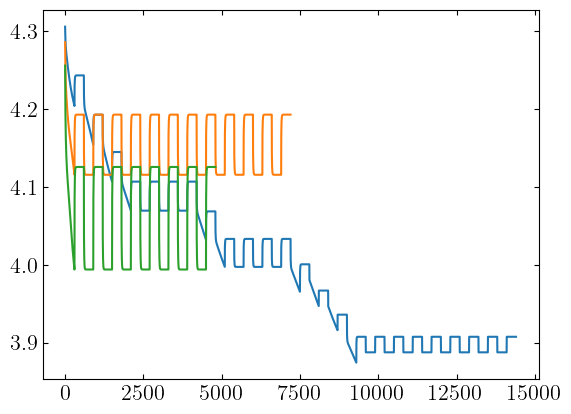

In [ ]:
def R0(i, d, SOC):
    return 0.01

def R1(i, d, SOC,R1_func = R1_func, Ref= REF_VALUES):
    return R1_func(i, d, SOC) * Ref['R1']

def C1(i, d, SOC,C1_func = C1_func, Ref= REF_VALUES):
    return C1_func(i, d, SOC) * Ref['C1']

def k(i, d, SOC):
    return k_func(i, d, SOC) * REF_VALUES['k']/100 


def time_current_profile(C_rate,mode = 'DC'):
    if mode == 'DC':
        t = np.arange(0, int(3600 / C_rate), DT)
        I = C_rate * Q0 / 3600 * np.ones_like(t)
        return I,t
    elif mode == 'pulse':
        pulse_duration = 300  # seconds
        pulse_current = C_rate * Q0 / 3600  # double the current for pulse
        t = np.arange(0, int(2*3600 / C_rate), DT)
        current = np.zeros_like(t)
        for start in range(0, len(t), pulse_duration*2):
            end = min(start + pulse_duration, len(t))
            current[start:end] = pulse_current
        return current, t
    else:
        raise ValueError("Invalid mode. Choose 'DC' or 'pulse'.")



def ECM_solve_du(u_par,C_rate, RC2 = False, U0 = 0, discharge = True):
    
    t = np.arange(0, int(3600 / C_rate), DT)
    # Create interpolation function ONCE
    
    i,t = time_current_profile(C_rate, mode='pulse')
    #i = C_rate * Q0 / 3600 * np.ones_like(t)  # Assuming constant current for simplicity


    if not discharge:
        i = -i
        soc0 = 0
    else:        
        soc0 = 1

    I_interp = interp1d(t, i, fill_value="extrapolate")


    def dSOC(SOC, t):
        I_t = I_interp(t)
        return -I_t / Q0
    
    
    def SOC(t,SOC0=soc0):
        SOC_t = scipy.integrate.odeint(dSOC, SOC0, t).flatten()
        return SOC_t
    
    SOC_t = SOC(t)
    soc_interp = interp1d(t, SOC_t, fill_value="extrapolate")

    def dU(V_1, t, soc_int = soc_interp, d = u_par):
        I_t = I_interp(t)
        SOC_t = soc_int(t)
        if not discharge:
            SOC_t = 1 - SOC_t
        R = R1(C_rate, d, SOC_t)
        C = C1(C_rate, d, SOC_t)
        return -V_1 / (R * C) + I_t / C 
    
    def mech(t, soc_int = soc_interp, d = u_par):
        SOC_t = soc_int(t)
        return k(C_rate, d, SOC_t)*d

    # Solve ODE
    
    U1 = scipy.integrate.odeint(dU, U0, t).flatten()

    # if RC2:
    #     U2 = scipy.integrate.odeint(dU, U0, t, args=(theta[3],theta[4])).flatten()
    # else: 
    #     U2 = 0
    #U2 = 0

    U = U1 #+ U2
    # Voltage model
    eta_model =  i*R0(C_rate,u_par,SOC_t) + U
    # if not discharge:
    #     eta_model = -eta_model
    V_B = GP.soc_to_Ue(SOC_t, GP_FIT) - eta_model

    if not discharge:
        valid_inds = V_B< 5.8
    else:
        valid_inds = V_B> 2.3
    V_B = V_B[valid_inds]
    t = t[valid_inds]
    soc = soc_interp(t)
    Ue = GP.soc_to_Ue(soc, GP_FIT)
    i = i[valid_inds]

    return V_B,soc, Ue,i ,t, mech(t)


for C_rate in np.arange(0.5, 2, 0.5):
    V_B,soc,Ue,i,t,F = ECM_solve_du(1,C_rate, discharge=True)
    plt.plot(t, V_B, label=f'C={C_rate}x')
plt.plot(np.linspace(0,1,100), GP.soc_to_Ue(np.linspace(0,1,100), GP_FIT), color = 'k',ls = '--', label='True $U_e$')
plt.show()

# for u in np.arange(1, 29, 5):
#     V_B,soc,Ue,i,t,F = ECM_solve_du(u,2)
#     plt.scatter(u, F.min(), label=f'u={u}')
#     plt.scatter(u, F.max(), label=f'u={u}')


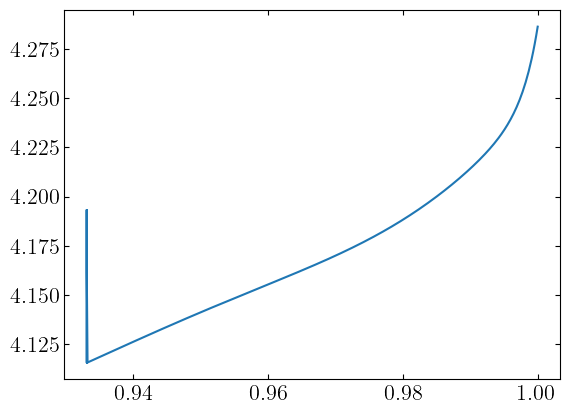

In [200]:
V_B,soc,Ue,i,t,F = ECM_solve_du(0.1,1, discharge = True)
plt.plot(soc, V_B, label=f'C={C_rate}x')

In [ ]:
def prepare_data(data, index = 0, test = False):
    if test:
        i = index + int(0.8*len(data['trajectory'].unique()))
    else:
        i = index
    trajs = data[data['trajectory'] == i].reset_index(drop=True)

    return trajs

In [ ]:


def read_data(file_name):
    df = pd.read_csv(
        f"symbol_data/{file_name}.txt",
        sep=',',
        comment="%"
    )
    # cols = u_par,C,t,V,I,F,u,Ue,eta,trajectory,dV,dF,soc
    #df.columns = ['u_par','C','t','V','I','F','u','Ue','eta','trajectory','dV','dF','soc']
    # Sort by time within each batch
    return df


path = f'ecm_node_elements_0429_1012_staged_funcR0_unconstr_pulse_1.32min_32h_1000_0eps'

data = read_data(path)


data['k'] = data['k'] * 100

k_ref = data['k'].mean() 
print(f'k_ref: {k_ref:.5f} GN/mm')
REF_VALUES = {
    'R1': 0.01,
    'C1': 1000,
    'k': k_ref}

display(data.head())

N_TRAJS = len(data['trajectory'].unique())
print(f'Number of trajectories: {N_TRAJS}')

k_ref: 3.18588 GN/mm


,trajectory,C,u_per,I,u,soc,R1,C1,R0,k
0,0,0.56,26.5,2.787801,-3.808911,1.000000,0.008427,774.54987,0.008969,3.212417
1,0,0.56,26.5,2.787801,-3.808911,0.999844,0.008426,774.55980,0.008969,3.212486
2,0,0.56,26.5,2.787801,-3.808911,0.999689,0.008426,774.56970,0.008969,3.212555
3,0,0.56,26.5,2.787801,-3.808911,0.999533,0.008426,774.57965,0.008969,3.212625
4,0,0.56,26.5,2.787801,-3.808911,0.999378,0.008426,774.58950,0.008969,3.212694


Number of trajectories: 100


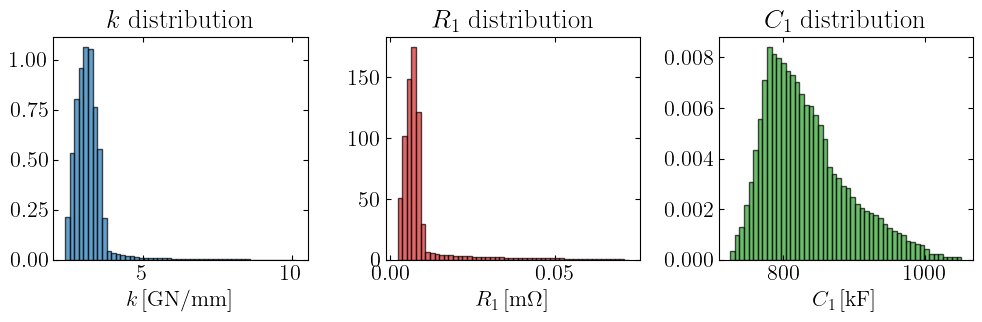

In [ ]:
f,ax = plt.subplots(1,3, figsize=(10,3.5))
ax[0].hist(data['k'], bins=50, color=colors[0], alpha=0.7,edgecolor='black', density=True)
ax[0].set_title(r'$k$ distribution')
ax[0].set_xlabel(r'$k\,$[GN/mm]')

ax[1].hist(data['R1'], bins=50, color=colors[1], alpha=0.7,edgecolor='black', density=True)
ax[1].set_title(r'$R_1$ distribution')
ax[1].set_xlabel(r'$R_1\,$[m$\Omega$]')

ax[2].hist( data['C1'], bins=50, color=colors[2], alpha=0.7,edgecolor='black', density=True)
ax[2].set_title(r'$C_1$ distribution')
ax[2].set_xlabel(r'$C_1\,$[kF]')
plt.tight_layout()


In [ ]:
def get_XY(d_frame):
    for i in range(1,10):
        inds = np.arange(0,len(d_frame)) % i == 0
        if inds.sum() < 1e5:
            break

    X = d_frame[['C', 'u_per', 'soc']].values
    Y_R1 = d_frame['R1'].values / REF_VALUES['R1']
    Y_C1 = d_frame['C1'].values / REF_VALUES['C1']
    Y_k  = d_frame['k'].values  / REF_VALUES['k']
    print(f'Using every {i}th data point for symbolic regression, total points: {inds.sum()}')
    
    return X[inds], Y_R1[inds], Y_C1[inds], Y_k[inds]

In [ ]:
split_train = int(data['trajectory'].max() * 0.8)
data_train = data[data['trajectory'] <= split_train]
data_test = data[data['trajectory'] > split_train]
trajs_train = prepare_data(data_train)
trajs_test = prepare_data(data_test)

X_train, YR1_train, YC_train, Yk_train = get_XY(data_train)

X_test,  YR1_test, YC_test, Yk_test = get_XY(data_test)

Using every 4th data point for symbolic regression, total points: 38825
Using every 1th data point for symbolic regression, total points: 12604


In [ ]:
def print_models(df_model):
    for i in range(len(df_model)):
        print(f"Model {i}: Complexity={df_model['complexity'][i]}, Loss={df_model['loss'][i]}")
        print(f"Equation: {df_model['equation'][i]}\n")

def print_best_model(model, model_index = None):
    best = model.get_best()
    display(Math(f'\\LARGE {model.latex(model_index)}'))
    display(Math(r'\LARGE $x_0 = \mathrm{{c}}$-rate$'))
    display(Math(r'\LARGE $x_1 = \Delta u / L_{{tot}}$'))
    display(Math(r'\LARGE $x_2 = \mathrm{SOC}$'))
    print(f'Best model in symbolic form: {model.sympy()}\nLoss: {best["loss"]}\nBest model complexity: {best["complexity"]}')

In [ ]:
# Parity plot
def pareto_plot(model):
    df_model = model.equations_
    best = model.get_best()
    plt.grid(True, which="both", ls="-", linewidth=0.5)
    plt.plot(df_model['complexity'], df_model['loss'], marker='o', linestyle='-', color=colors[0], label='Models')
    plt.plot(best['complexity'], best['loss'],'o', color=colors[1], label='Best Model')
    plt.xlabel('Complexity')
    plt.ylabel('Loss')
    plt.yscale('log')
    plt.title('Model Complexity vs Loss')
    plt.legend()
    plt.show()

def parity_plot(element,model, X_test = X_test, Yk_test = Yk_test, YC_test = YC_test, Y_R1_test = YR1_test):
    if element == 'R1':
        Y_test = YR1_test
    elif element == 'k':
        Y_test = Yk_test
    elif element == 'C1':
        Y_test = YC_test

    Y_pred = model.predict(X_test)
    plt.scatter(Y_test, Y_pred, color=colors[0],alpha = 0.5)
    plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'k--', lw=2)
    plt.xlabel(f'Actual ${element}$ [a.u.]')
    plt.ylabel(f'Predicted ${element}$ [a.u.]')
    plt.show()

def save_expressions(df_model, element):
    df_model.to_csv(f'model_{element}.csv', index=False)

# $k = f_k(i,d,\mathrm{SOC})$

In [ ]:
import_reload()
model_k = Param_symbol.run_symbolic_regression(X_train, Yk_train, model = None,run_id = f'k_{RUN_ID}')

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


In [ ]:
df_model_k = model_k.equations_

In [ ]:
print_models(df_model_k)

Model 0: Complexity=1, Loss=0.0346423
Equation: 0.9993777

Model 1: Complexity=4, Loss=0.024332495
Equation: exp(0.32707214 / x1)

Model 2: Complexity=5, Loss=0.019838559
Equation: exp(exp(0.1397952 - x1))

Model 3: Complexity=6, Loss=0.012597735
Equation: exp((0.8308478 - x2) / x1)

Model 4: Complexity=8, Loss=0.010813713
Equation: exp((0.8308478 - x2) / x1) * 0.9702479

Model 5: Complexity=9, Loss=0.0070753586
Equation: exp((2.607258 / exp(x1)) - (x2 / x1))

Model 6: Complexity=10, Loss=0.006460695
Equation: (3.214673 / exp(x1)) - ((x2 / x1) + -1.0156077)

Model 7: Complexity=11, Loss=0.0048162676
Equation: ((2.7890403 / exp(x1)) - (x2 / sqrt(x1))) + 1.1239563

Model 8: Complexity=12, Loss=0.0043364153
Equation: ((sqrt(2.5819283 / exp(x1)) - x2) / sqrt(x1)) + 1.1129624

Model 9: Complexity=13, Loss=0.0034570042
Equation: exp(sqrt(2.2804518 / exp(x1)) - (x2 / exp(x1 * 0.1600363)))

Model 10: Complexity=14, Loss=0.0034456323
Equation: exp(sqrt(2.2945275 / exp(x1)) - (x2 / sqrt(exp(x1 *

In [ ]:
print_best_model(model_k)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: 1.09232756468318*exp(-x2*exp(-0.0996344*x1) + 1.42746534108538*sqrt(exp(-x1)))
Loss: 0.0016245331
Best model complexity: 15


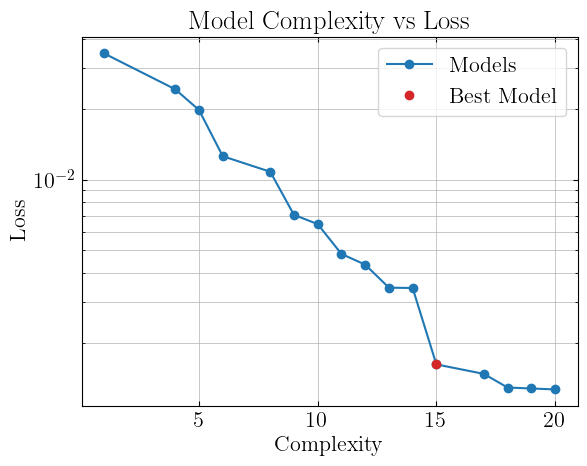

In [ ]:
pareto_plot(model_k)

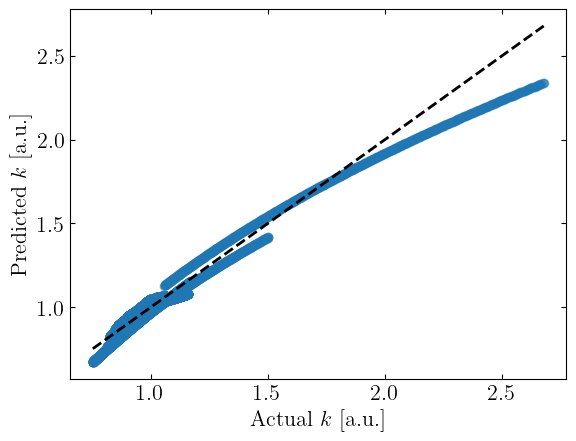

In [ ]:
parity_plot('k',model_k)

# $R_1 = f_R(i,u,\mathrm{SOC})$

In [ ]:
import_reload()
model_R1 = Param_symbol.run_symbolic_regression(X_train, YR1_train, model = None,run_id = f'R1_{RUN_ID}')

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


In [ ]:
df_model_R1 = model_R1.equations_

In [ ]:
print_models(df_model_R1)

Model 0: Complexity=1, Loss=0.9133004
Equation: 0.91823286

Model 1: Complexity=2, Loss=0.8762339
Equation: cos(x2)

Model 2: Complexity=3, Loss=0.25899288
Equation: 0.27675372 / x2

Model 3: Complexity=4, Loss=0.24762727
Equation: 0.27489594 / sin(x2)

Model 4: Complexity=5, Loss=0.23949805
Equation: 0.27382055 / sin(sin(x2))

Model 5: Complexity=6, Loss=0.19825439
Equation: cube(x2) + (0.25880274 / x2)

Model 6: Complexity=7, Loss=0.16818573
Equation: square(log(x2 + x2)) - -0.26026067

Model 7: Complexity=8, Loss=0.10428694
Equation: cube(square(tan(0.97936827 - x2))) + x2

Model 8: Complexity=9, Loss=0.10329456
Equation: x2 + square(cube(tan(tan(x2) - 0.98009384)))

Model 9: Complexity=10, Loss=0.09807092
Equation: square(square(square((x2 + -0.7437257) / -0.55669475))) + x2

Model 10: Complexity=11, Loss=0.097565256
Equation: square(square(square((x2 + -0.7437257) / -0.55669475))) + sin(x2)

Model 11: Complexity=12, Loss=0.023204561
Equation: x2 + square((x0 - -3.454991) * cube(sq

In [ ]:
print_best_model(model_R1)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: x2 + 5.37545801772978*(x0 - 1*(-2.7120254))**2*(x2 - 0.86572266)**12
Loss: 0.017738784
Best model complexity: 14


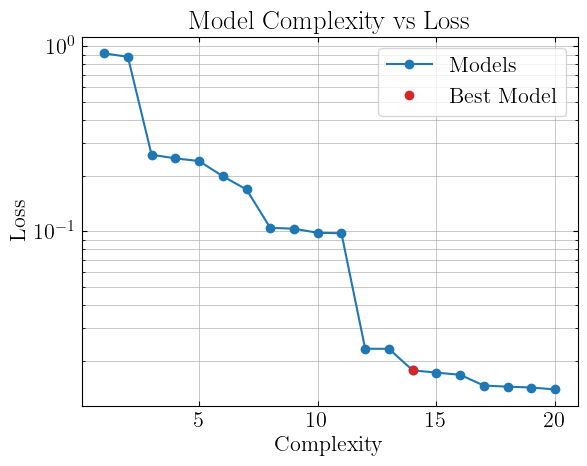

In [ ]:
pareto_plot(model_R1)

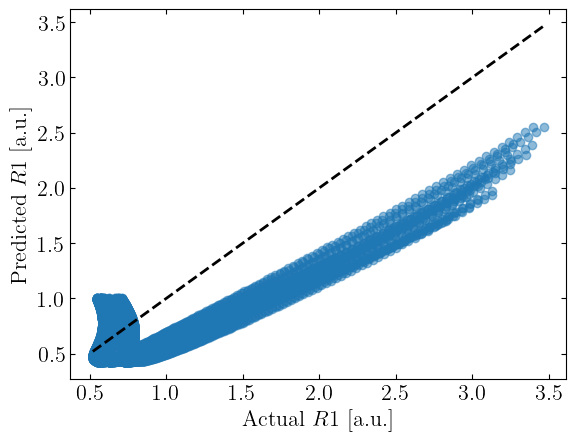

In [ ]:
parity_plot('R1',model_R1)

In [ ]:
#df_model_R1.to_csv('model_R1.csv', index=False)
#df_model_C1.to_csv('model_C1.csv', index=False)

# $C_1 = f_C(i,u,\mathrm{SOC})$

In [ ]:
import_reload()
model_C1 = Param_symbol.run_symbolic_regression(X_train, YC_train, model = None,run_id = f'C1_{RUN_ID}')

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


In [ ]:
df_model_C1 = model_C1.equations_

In [ ]:
print_models(df_model_C1)

Model 0: Complexity=1, Loss=0.00341904
Equation: 0.83645433

Model 1: Complexity=4, Loss=0.0032397767
Equation: sqrt(sin(cos(x2)))

Model 2: Complexity=5, Loss=0.0019983125
Equation: (x1 * -0.004375736) + 0.90018785

Model 3: Complexity=6, Loss=0.0017820541
Equation: (sqrt(x1) * -0.033498026) + 0.9584166

Model 4: Complexity=7, Loss=0.0015340806
Equation: (0.66018265 / (x1 + x0)) + 0.77707154

Model 5: Complexity=8, Loss=0.0009223938
Equation: (cos(x2) / (x1 + x0)) + 0.76199955

Model 6: Complexity=9, Loss=0.00045247248
Equation: ((1.1915016 - x2) / (x0 + x1)) + 0.7773231

Model 7: Complexity=10, Loss=0.00039154803
Equation: (cos(sqrt(x2)) / log(x1 + 6.4518366)) + 0.5776201

Model 8: Complexity=11, Loss=0.00031152755
Equation: (cos(x2) / log((x1 + x0) * 3.3202293)) + 0.61273414

Model 9: Complexity=12, Loss=0.00019193672
Equation: (cos(sqrt(x2)) / log((x0 + x1) / 0.37134206)) + 0.6220943

Model 10: Complexity=13, Loss=0.00018119154
Equation: (cos(sqrt(sqrt(x2))) / log((x1 + x0) + 3.185

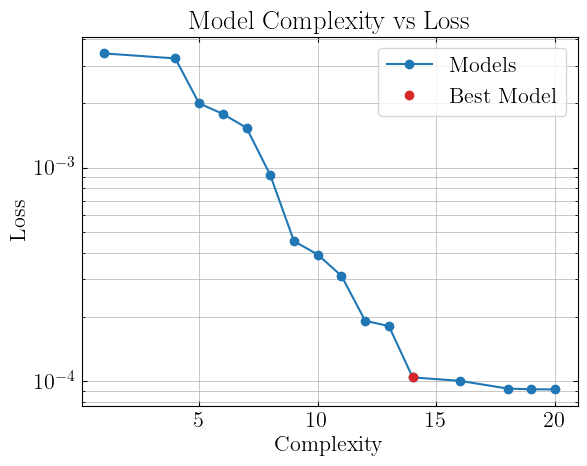

In [ ]:
pareto_plot(model_C1)

In [ ]:
print_best_model(model_C1)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: 0.6259464 + cos(sqrt(x2))/log((x0 + 1.4045959)*(x1 + 1.650313))
Loss: 0.00010427262
Best model complexity: 14


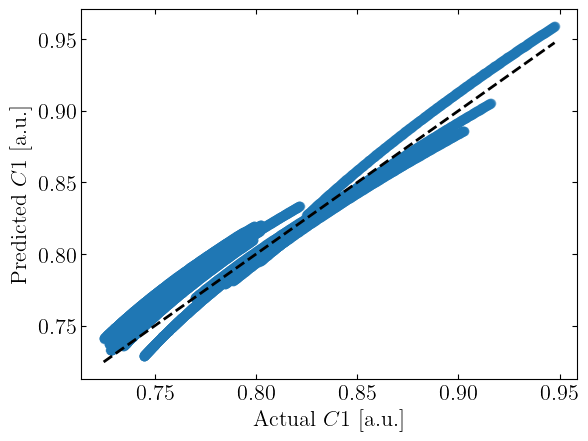

In [ ]:
parity_plot('C1', model_C1)

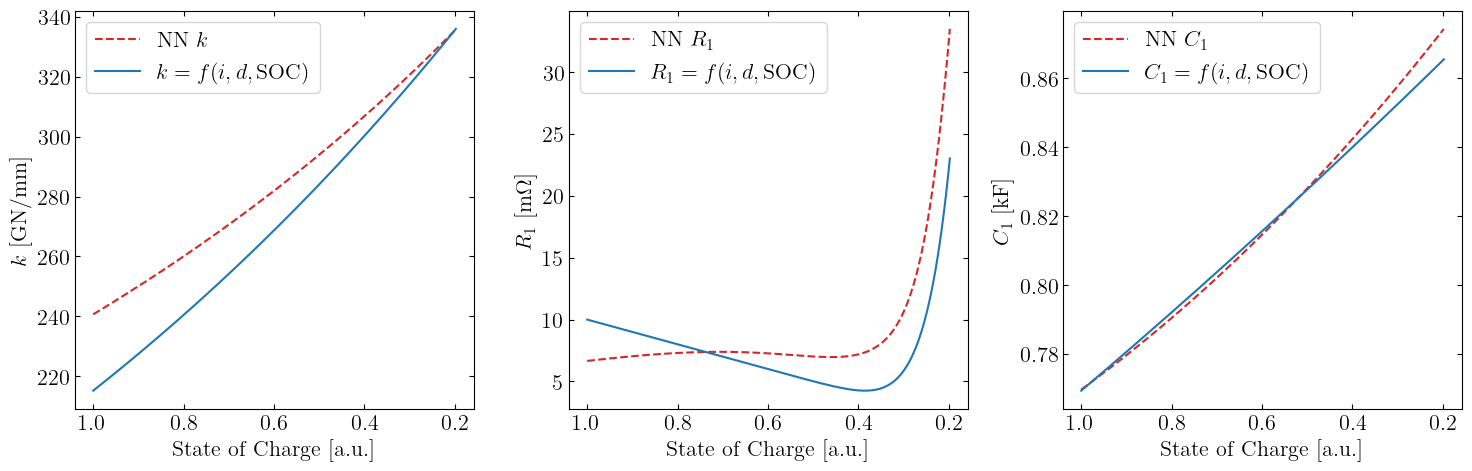

In [ ]:
def plot_trajs_SOC(data = data, ind = 0, modelR = model_R1, modelC = model_C1,model_0 = model_k, test = False):
    tr = prepare_data(data, index = ind, test=test)
    X = tr[['C', 'u_per', 'soc']].values
    Yk_pred =  model_0.predict(X) * REF_VALUES['k'] * 100
    YR1_pred = modelR.predict(X) * REF_VALUES['R1'] * 1000
    YC_pred =  modelC.predict(X) * REF_VALUES['C1'] / 1000
    f,ax = plt.subplots(1,3, figsize=(15,5))
    ax[0].plot(tr['soc'], tr['k'] * 100, label=r'NN $k$',  color=colors[1], linestyle='--')
    ax[0].plot(tr['soc'], Yk_pred, label=r'$k = f(i,d,\mathrm{SOC})$',color=colors[0])
    ax[1].plot(tr['soc'], tr['R1'] * 1000, label=r'NN $R_1$',  color=colors[1], linestyle='--')
    ax[1].plot(tr['soc'], YR1_pred, label=r'$R_1 = f(i,d,\mathrm{SOC})$',color=colors[0])
    ax[2].plot(tr['soc'], tr['C1'] / 1000, label=r'NN $C_1$', color=colors[1], linestyle='--')
    ax[2].plot(tr['soc'], YC_pred, label=r'$C_1 = f(i,d,\mathrm{SOC})$', color=colors[0])
    for a in ax:
        a.set_xlabel('State of Charge [a.u.]')
        a.legend()
        a.invert_xaxis()
    ax[0].set_ylabel(r'$k$ [GN/mm]');ax[2].set_ylabel(r'$C_1$ [kF]');ax[1].set_ylabel(r'$R_1$ [m$\Omega$]') 

    plt.tight_layout()
    plt.savefig('symbolic_traj_test.pdf')

plot_trajs_SOC(test = True, ind = 4)

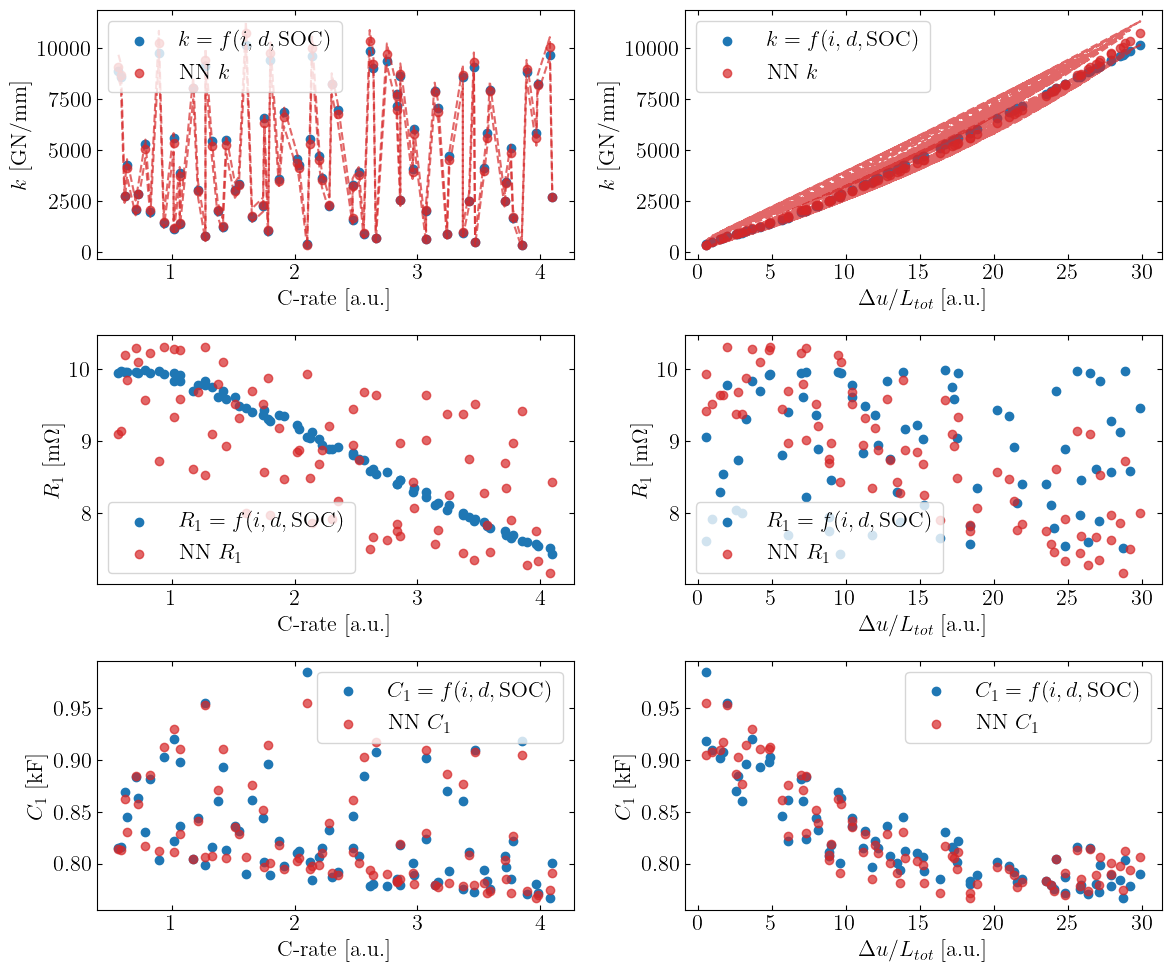

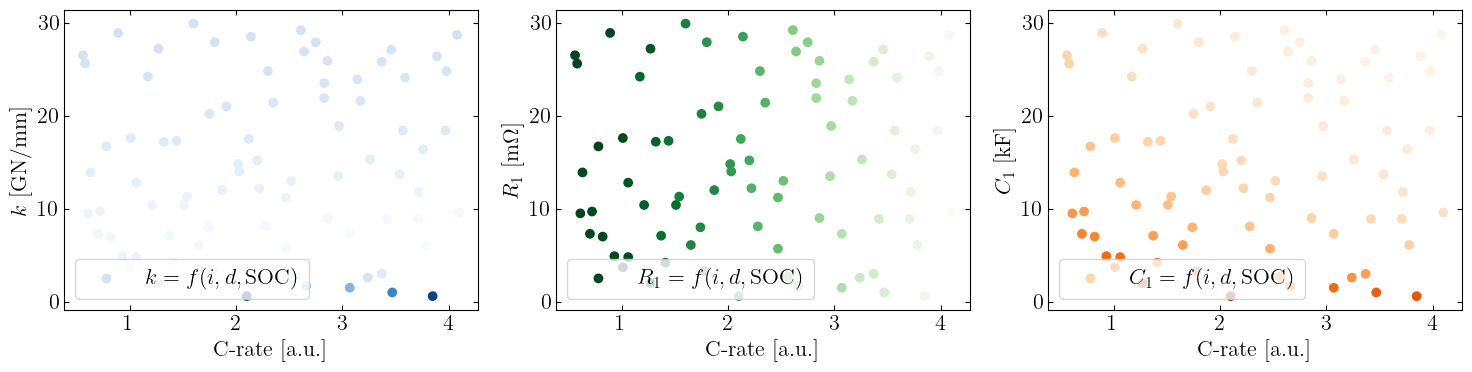

In [ ]:
def plot_trajs_C_d(data = data, modelR = model_R1, modelC = model_C1,model_0 = model_k, test = False):
    f,axs = plt.subplots(3,2, figsize=(12,10))
    
    train_index = int(0.8 * N_TRAJS )
    test_index = int(N_TRAJS - train_index)
    if test:
        ind = test_index
    else:
        ind = train_index
    i=0
    k_pred = np.zeros((ind,3)); R1_pred = np.zeros((ind,3)); C1_pred = np.zeros((ind,3))
    k_true = np.zeros((ind,3)); R1_true = np.zeros((ind,3)); C1_true = np.zeros((ind,3))
    X_vals = np.zeros((ind,2))    
    while i < ind:
        tr = prepare_data(data, index = i, test=test)
        X = tr[['C', 'u_per', 'soc']].values
        Yk_pred =  model_0.predict(X) * REF_VALUES['k'] * 100
        YR1_pred = modelR.predict(X) * REF_VALUES['R1'] * 1000
        YC_pred =  modelC.predict(X) * REF_VALUES['C1'] / 1000
        
        k_pred[i,0] = Yk_pred.mean(); R1_pred[i,0] = YR1_pred.mean(); C1_pred[i,0] = YC_pred.mean()
        k_pred[i,1] = Yk_pred.min(); R1_pred[i,1] = YR1_pred.min(); C1_pred[i,1] = YC_pred.min()
        k_pred[i,2] = Yk_pred.max(); R1_pred[i,2] = YR1_pred.max(); C1_pred[i,2] = YC_pred.max()

        k_true[i,0] = tr['k'].mean() * 100; R1_true[i,0] = tr['R1'].mean() * 1000; C1_true[i,0] = tr['C1'].mean() / 1000
        k_true[i,1] = tr['k'].min() * 100; R1_true[i,1] = tr['R1'].min() * 1000; C1_true[i,1] = tr['C1'].min() / 1000
        k_true[i,2] = tr['k'].max() * 100; R1_true[i,2] = tr['R1'].max() * 1000; C1_true[i,2] = tr['C1'].max() / 1000
        X_vals[i,0] = X[0,0]; X_vals[i,1] = X[0,1]
        i += 1

    for j in range(len(axs[0,:])):
        ax = axs[:,j]
        x = X_vals[:,j]
        ax[0].scatter(x, k_pred[:,0] * X_vals[:,1], label=r'$k = f(i,d,\mathrm{SOC})$',color=colors[0])
        ax[0].scatter(x, k_true[:,0] * X_vals[:,1], label=r'NN $k$',  color=colors[1], alpha=0.7)
        ax[0].plot(x, k_true[:,1] * X_vals[:,1], color=colors[1], alpha=0.7, linestyle='--')
        ax[0].plot(x, k_true[:,2] * X_vals[:,1], color=colors[1], alpha=0.7, linestyle='--')
        #ax[0].fill_between(x, k_true[:,1] * X_vals[:,1], k_true[:,2] * X_vals[:,1], color=colors[1], alpha=0.2, label='NN range')
        #ax[1].fill_between(x, R1_true[:,1] , R1_true[:,2], color=colors[1], alpha=0.2, label='NN range')
        #ax[2].fill_between(x, C1_true[:,1], C1_true[:,2], color=colors[1], alpha=0.2, label='NN range')

        ax[1].scatter(x, R1_pred[:,0], label=r'$R_1 = f(i,d,\mathrm{SOC})$',color=colors[0])
        ax[1].scatter(x, R1_true[:,0], label=r'NN $R_1$',  color=colors[1], alpha=0.7)
        ax[2].scatter(x, C1_pred[:,0], label=r'$C_1 = f(i,d,\mathrm{SOC})$', color=colors[0])
        ax[2].scatter(x, C1_true[:,0], label=r'NN $C_1$', color=colors[1], alpha=0.7)
        ax[0].set_ylabel(r'$k$ [GN/mm]');ax[2].set_ylabel(r'$C_1$ [kF]');ax[1].set_ylabel(r'$R_1$ [m$\Omega$]') 
        
        ax[0].legend(); ax[1].legend(); ax[2].legend()
    for a in axs[:,0]:
        a.set_xlabel('C-rate [a.u.]')
    for a in axs[:,1]:
        a.set_xlabel(r'$\Delta u / L_{tot}$ [a.u.]')
    # for tr in test_trajs:
    #     X = tr[['C', 'u_per', 'soc']].values
    #     Yk_pred =  model_0.predict(X) * REF_VALUES['k'] * 100
    #     YR1_pred = modelR.predict(X) * REF_VALUES['R1'] * 1000
    #     YC_pred =  modelC.predict(X) * REF_VALUES['C1'] / 1000
    #     f,ax = plt.subplots(1,3, figsize=(15,5))
    #     ax[0].plot(tr['C'], tr['k'] * 100, label=r'NN $k$',  color=colors[1], linestyle='--')
    #     ax[0].plot(tr['C'], Yk_pred, label=r'$k = f(i,d,\mathrm{SOC})$',color=colors[0])
    #     ax[1].plot(tr['C'], tr['R1'] * 1000, label=r'NN $R_1$',  color=colors[1], linestyle='--')
    #     ax[1].plot(tr['C'], YR1_pred, label=r'$R_1 = f(i,d,\mathrm{SOC})$',color=colors[0])
    #     ax[2].plot(tr['C'], tr['C1'] / 1000, label=r'NN $C_1$', color=colors[1], linestyle='--')
    #     ax[2].plot(tr['C'], YC_pred, label=r'$C_1 = f(i,d,\mathrm{SOC})$', color=colors[0])
    #     for a in ax:
    #         a.set_xlabel('C-rate [a.u.]')
    #         a.legend()
    #         a.invert_xaxis()
        
            
         
    plt.tight_layout()

    plt.show()
    f,ax = plt.subplots(1,3, figsize=(15,4))
    ax[0].scatter(X_vals[:,0],X_vals[:,1],c= k_pred[:,0], label=r'$k = f(i,d,\mathrm{SOC})$',cmap = 'Blues')
    ax[0].set_xlabel('C-rate [a.u.]')
    ax[0].set_ylabel(r'$k$ [GN/mm]')
    ax[0].legend()
    ax[1].scatter(X_vals[:,0],X_vals[:,1],c= R1_pred[:,0], label=r'$R_1 = f(i,d,\mathrm{SOC})$',cmap = 'Greens')
    ax[1].set_xlabel('C-rate [a.u.]')
    ax[1].set_ylabel(r'$R_1$ [m$\Omega$]')
    ax[1].legend()
    ax[2].scatter(X_vals[:,0],X_vals[:,1],c= C1_pred[:,0], label=r'$C_1 = f(i,d,\mathrm{SOC})$',cmap = 'Oranges')
    ax[2].set_xlabel('C-rate [a.u.]')
    ax[2].set_ylabel(r'$C_1$ [kF]')
    ax[2].legend()
    plt.tight_layout()

plot_trajs_C_d(test = False)

In [ ]:
f,ax = plt.subplots(1,3, figsize=(15,5))

In [ ]:
SAVE  = True
if SAVE:
    save_expressions(df_model_k,  f'k_{RUN_ID}')
    save_expressions(df_model_R1, f'R1_{RUN_ID}')
    save_expressions(df_model_C1, f'C1_{RUN_ID}')